In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [10]:
import torch

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    free_memory, total_memory = torch.cuda.mem_get_info()

    print(
        f"Free memory: "
        f"{free_memory / 1024**3:.2f} GB"
    )

    print(
        f"Total memory: "
        f"{total_memory / 1024**3:.2f} GB"
    )

Device: cuda:0
GPU: NVIDIA GeForce RTX 2080 Ti
Free memory: 10.26 GB
Total memory: 10.57 GB


In [11]:
import os

# Same GPU setup as your existing experiment
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import RGCNConv


# ============================================================
# Paths
# ============================================================

PROJECT_DIR = Path("/workspace/primekg_ddi_rgcn")

TENSOR_DIR = PROJECT_DIR / "data/processed/rgcn_tensors"

CHECKPOINT_DIR = (
    PROJECT_DIR
    / "checkpoints/relation_ablation"
)

RESULT_DIR = (
    PROJECT_DIR
    / "results/relation_ablation"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# Fixed configuration
# SAME as your existing experiment
# ============================================================

CONFIG = {
    "num_nodes": 13094,
    "num_relations": 15,

    "embedding_dim": 128,
    "hidden_dim": 128,

    "dropout": 0.2,

    "learning_rate": 1e-3,
    "weight_decay": 1e-5,

    "epochs": 100,

    "early_stopping_patience": 10,

    "train_positives_per_epoch": 100_000
}


print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("\nConfiguration:")
print(
    json.dumps(
        CONFIG,
        indent=2
    )
)


Device: cuda:0
GPU: NVIDIA GeForce RTX 2080 Ti

Configuration:
{
  "num_nodes": 13094,
  "num_relations": 15,
  "embedding_dim": 128,
  "hidden_dim": 128,
  "dropout": 0.2,
  "learning_rate": 0.001,
  "weight_decay": 1e-05,
  "epochs": 100,
  "early_stopping_patience": 10,
  "train_positives_per_epoch": 100000
}


In [12]:
# ============================================================
# Load FIXED DDI training/evaluation data
# ============================================================

train_data = torch.load(
    TENSOR_DIR / "ddi_train.pt",
    map_location="cpu"
)

val_data = torch.load(
    TENSOR_DIR / "ddi_val.pt",
    map_location="cpu"
)

test_data = torch.load(
    TENSOR_DIR / "ddi_test.pt",
    map_location="cpu"
)

train_negative_data = torch.load(
    TENSOR_DIR / "ddi_train_negatives.pt",
    map_location="cpu"
)

val_negative_data = torch.load(
    TENSOR_DIR / "ddi_val_negatives.pt",
    map_location="cpu"
)


train_pair_index = train_data[
    "pair_index"
]

val_pair_index = val_data[
    "pair_index"
]

test_pair_index = test_data[
    "pair_index"
]

train_negative_pair_index = train_negative_data[
    "pair_index"
]

val_negative_pair_index = val_negative_data[
    "pair_index"
]


print(
    "Train positives:",
    train_pair_index.shape
)

print(
    "Train negatives:",
    train_negative_pair_index.shape
)

print(
    "Validation positives:",
    val_pair_index.shape
)

print(
    "Validation negatives:",
    val_negative_pair_index.shape
)

print(
    "Test positives:",
    test_pair_index.shape
)

Train positives: torch.Size([2, 1069080])
Train negatives: torch.Size([2, 1069080])
Validation positives: torch.Size([2, 133620])
Validation negatives: torch.Size([2, 133620])
Test positives: torch.Size([2, 133614])


In [13]:
# ============================================================
# R-GCN model
# SAME architecture as G0-G3
# ============================================================

class RGCNDDIModel(nn.Module):

    def __init__(
        self,
        num_nodes,
        num_relations,
        embedding_dim=128,
        hidden_dim=128,
        dropout=0.2
    ):
        super().__init__()

        self.node_embedding = nn.Embedding(
            num_nodes,
            embedding_dim
        )

        self.conv1 = RGCNConv(
            embedding_dim,
            hidden_dim,
            num_relations
        )

        self.conv2 = RGCNConv(
            hidden_dim,
            hidden_dim,
            num_relations
        )

        self.dropout = dropout

        # Symmetric DDI decoder
        self.ddi_relation = nn.Parameter(
            torch.empty(hidden_dim)
        )

        self.reset_parameters()


    def reset_parameters(self):

        nn.init.xavier_uniform_(
            self.node_embedding.weight
        )

        self.conv1.reset_parameters()
        self.conv2.reset_parameters()

        nn.init.ones_(
            self.ddi_relation
        )


    def encode(
        self,
        edge_index,
        edge_type
    ):

        x = self.node_embedding.weight

        x = self.conv1(
            x,
            edge_index,
            edge_type
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index,
            edge_type
        )

        return x


    def decode(
        self,
        z,
        pair_index
    ):

        src = pair_index[0]
        dst = pair_index[1]

        scores = (
            z[src]
            * self.ddi_relation
            * z[dst]
        ).sum(
            dim=-1
        )

        return scores

In [20]:
def reset_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [14]:
TRAIN_POSITIVES_PER_EPOCH = 100_000


def train_one_epoch(
    model,
    optimizer,
    epoch,
    seed,
    edge_index,
    edge_type,
    positive_pairs,
    negative_pairs
):

    model.train()

    generator = torch.Generator()

    generator.manual_seed(
        seed + epoch
    )


    num_pos = positive_pairs.shape[1]
    num_neg = negative_pairs.shape[1]


    pos_idx = torch.randperm(
        num_pos,
        generator=generator
    )[:TRAIN_POSITIVES_PER_EPOCH]


    neg_idx = torch.randperm(
        num_neg,
        generator=generator
    )[:TRAIN_POSITIVES_PER_EPOCH]


    sampled_positive = (
        positive_pairs[
            :,
            pos_idx
        ]
    )


    sampled_negative = (
        negative_pairs[
            :,
            neg_idx
        ]
    )


    pair_index = torch.cat(
        [
            sampled_positive,
            sampled_negative
        ],
        dim=1
    ).to(device)


    labels = torch.cat(
        [
            torch.ones(
                TRAIN_POSITIVES_PER_EPOCH
            ),

            torch.zeros(
                TRAIN_POSITIVES_PER_EPOCH
            )
        ]
    ).to(device)


    optimizer.zero_grad(
        set_to_none=True
    )


    z = model.encode(
        edge_index,
        edge_type
    )


    logits = model.decode(
        z,
        pair_index
    )


    loss = (
        F.binary_cross_entropy_with_logits(
            logits,
            labels
        )
    )


    loss.backward()

    optimizer.step()


    return loss.item()

In [15]:
@torch.no_grad()
def validation_loss(
    model,
    edge_index,
    edge_type,
    positive_pairs,
    negative_pairs
):

    model.eval()


    pair_index = torch.cat(
        [
            positive_pairs,
            negative_pairs
        ],
        dim=1
    ).to(device)


    labels = torch.cat(
        [
            torch.ones(
                positive_pairs.shape[1]
            ),

            torch.zeros(
                negative_pairs.shape[1]
            )
        ]
    ).to(device)


    z = model.encode(
        edge_index,
        edge_type
    )


    logits = model.decode(
        z,
        pair_index
    )


    loss = (
        F.binary_cross_entropy_with_logits(
            logits,
            labels
        )
    )


    return loss.item()

In [16]:
def train_ablation(
    graph_name,
    seed
):

    print("\n")
    print("=" * 70)
    print(
        f"TRAINING {graph_name} | SEED {seed}"
    )
    print("=" * 70)


    # ========================================================
    # Reset randomness
    # ========================================================

    reset_seed(seed)


    # ========================================================
    # Load graph
    # ========================================================

    graph_data = torch.load(
        TENSOR_DIR
        / f"{graph_name}.pt",
        map_location="cpu"
    )


    edge_index = (
        graph_data["edge_index"]
        .to(device)
    )


    edge_type = (
        graph_data["edge_type"]
        .to(device)
    )


    print(
        "Edges:",
        f"{edge_index.shape[1]:,}"
    )


    print(
        "Active relations:",
        torch.unique(
            edge_type
        ).sort().values.tolist()
    )


    print(
        "num_relations:",
        graph_data["num_relations"]
    )


    assert (
        graph_data["num_nodes"]
        == CONFIG["num_nodes"]
    )


    assert (
        graph_data["num_relations"]
        == CONFIG["num_relations"]
    )


    # ========================================================
    # Fresh model
    # ========================================================

    model = RGCNDDIModel(
        num_nodes=CONFIG["num_nodes"],
        num_relations=CONFIG["num_relations"],
        embedding_dim=CONFIG["embedding_dim"],
        hidden_dim=CONFIG["hidden_dim"],
        dropout=CONFIG["dropout"]
    ).to(device)


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"]
    )


    # ========================================================
    # Paths
    # ========================================================

    best_path = (
        CHECKPOINT_DIR
        / f"{graph_name}_seed{seed}_best.pt"
    )


    latest_path = (
        CHECKPOINT_DIR
        / f"{graph_name}_seed{seed}_latest.pt"
    )


    # ========================================================
    # Early stopping state
    # ========================================================

    best_val_loss = float("inf")

    best_epoch = 0

    epochs_without_improvement = 0

    history = []


    MAX_EPOCHS = CONFIG["epochs"]

    PATIENCE = (
        CONFIG[
            "early_stopping_patience"
        ]
    )


    training_start = time.time()


    # ========================================================
    # Training loop
    # ========================================================

    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        epoch_start = time.time()


        train_loss = train_one_epoch(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            seed=seed,
            edge_index=edge_index,
            edge_type=edge_type,
            positive_pairs=train_pair_index,
            negative_pairs=train_negative_pair_index
        )


        val_loss = validation_loss(
            model=model,
            edge_index=edge_index,
            edge_type=edge_type,
            positive_pairs=val_pair_index,
            negative_pairs=val_negative_pair_index
        )


        if torch.cuda.is_available():
            torch.cuda.synchronize()


        epoch_time = (
            time.time()
            - epoch_start
        )


        history.append({
            "epoch": epoch,
            "train_loss":
                float(train_loss),

            "val_loss":
                float(val_loss),

            "time_seconds":
                float(epoch_time)
        })


        improved = (
            val_loss
            < best_val_loss
        )


        if improved:

            best_val_loss = (
                val_loss
            )

            best_epoch = epoch

            epochs_without_improvement = 0


            torch.save(
                {
                    "epoch":
                        epoch,

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "best_val_loss":
                        float(
                            best_val_loss
                        ),

                    "best_epoch":
                        best_epoch,

                    "history":
                        history,

                    "config":
                        CONFIG,

                    "graph":
                        graph_name,

                    "seed":
                        seed
                },
                best_path
            )


        else:

            epochs_without_improvement += 1


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_val_loss":
                    float(
                        best_val_loss
                    ),

                "best_epoch":
                    best_epoch,

                "epochs_without_improvement":
                    epochs_without_improvement,

                "history":
                    history,

                "config":
                    CONFIG,

                "graph":
                    graph_name,

                "seed":
                    seed
            },
            latest_path
        )


        marker = (
            " <-- BEST"
            if improved
            else ""
        )


        print(
            f"Epoch {epoch:03d} | "
            f"Train {train_loss:.6f} | "
            f"Val {val_loss:.6f} | "
            f"NoImprove "
            f"{epochs_without_improvement}"
            f"/{PATIENCE} | "
            f"{epoch_time:.2f}s"
            f"{marker}"
        )


        if (
            epochs_without_improvement
            >= PATIENCE
        ):

            print(
                "\nEARLY STOPPING"
            )

            break


    total_time = (
        time.time()
        - training_start
    )


    print("\nTraining finished.")

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Best validation loss:",
        f"{best_val_loss:.6f}"
    )

    print(
        "Training time:",
        f"{total_time:.2f}s"
    )

    print(
        "Best checkpoint:",
        best_path
    )


    # Free GPU memory before next experiment
    del model

    del edge_index
    del edge_type

    torch.cuda.empty_cache()


    return {
        "graph":
            graph_name,

        "seed":
            seed,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "training_time":
            total_time,

        "best_checkpoint":
            str(best_path)
    }

In [17]:
free_memory, total_memory = torch.cuda.mem_get_info()

print(
    f"Free: {free_memory / 1024**3:.2f} GB / "
    f"{total_memory / 1024**3:.2f} GB"
)

Free: 10.26 GB / 10.57 GB


In [18]:
result = train_ablation(
    graph_name="A1_target",
    seed=42
)

result



TRAINING A1_target | SEED 42


NameError: name 'reset_seed' is not defined

In [21]:
import random
import numpy as np
import torch


In [22]:
result = train_ablation(
    graph_name="A1_target",
    seed=42
)

result



TRAINING A1_target | SEED 42
Edges: 2,170,920
Active relations: [0, 1, 2]
num_relations: 15
Epoch 001 | Train 0.693147 | Val 0.692841 | NoImprove 0/10 | 0.69s <-- BEST
Epoch 002 | Train 0.692845 | Val 0.692263 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 003 | Train 0.692245 | Val 0.691173 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 004 | Train 0.691178 | Val 0.689311 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 005 | Train 0.689326 | Val 0.686340 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.686328 | Val 0.681851 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.681800 | Val 0.675421 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 008 | Train 0.675273 | Val 0.666796 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 009 | Train 0.666777 | Val 0.656313 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 010 | Train 0.656593 | Val 0.645570 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 011 | Train 0.645814 | Val 0.637237 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 012 | Train 0.637498 | Val 0.631070 | NoImprove 0/10 | 0.20s <--

{'graph': 'A1_target',
 'seed': 42,
 'best_epoch': 100,
 'best_val_loss': 0.43071722984313965,
 'training_time': 51.7461256980896,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A1_target_seed42_best.pt'}

In [23]:
# ============================================================
# Load ranking-evaluation artifacts
# ============================================================

drug_obj = torch.load(
    TENSOR_DIR / "drug_node_ids.pt",
    map_location="cpu"
)

drug_node_ids = drug_obj[
    "drug_node_ids"
].long()


known_obj = torch.load(
    TENSOR_DIR / "ddi_known_positive_mask.pt",
    map_location="cpu"
)

known_positive_mask = known_obj[
    "known_positive_mask"
].bool()


print(
    "Candidate drugs:",
    drug_node_ids.numel()
)

print(
    "Known-positive mask:",
    known_positive_mask.shape
)


Candidate drugs: 4278
Known-positive mask: torch.Size([4278, 4278])


In [24]:
@torch.no_grad()
def get_filtered_ranks(
    model,
    edge_index,
    edge_type,
    positive_pairs,
    drug_node_ids,
    known_positive_mask,
    batch_size=512
):
    model.eval()

    # Encode entire graph once
    z = model.encode(
        edge_index,
        edge_type
    )

    drug_ids_gpu = drug_node_ids.to(device)

    known_mask_gpu = (
        known_positive_mask.to(device)
    )

    candidate_z = z[
        drug_ids_gpu
    ]

    # --------------------------------------------------------
    # Evaluate BOTH directions:
    #
    # Drug A -> Drug B
    # Drug B -> Drug A
    # --------------------------------------------------------

    reverse_pairs = torch.stack(
        [
            positive_pairs[1],
            positive_pairs[0]
        ],
        dim=0
    )

    eval_pairs = torch.cat(
        [
            positive_pairs,
            reverse_pairs
        ],
        dim=1
    )

    source_global = (
        eval_pairs[0].to(device)
    )

    target_global = (
        eval_pairs[1].to(device)
    )

    # --------------------------------------------------------
    # Convert global node IDs into
    # local drug-candidate indices
    # --------------------------------------------------------

    source_local = torch.searchsorted(
        drug_ids_gpu,
        source_global
    )

    target_local = torch.searchsorted(
        drug_ids_gpu,
        target_global
    )

    # Safety checks
    assert torch.equal(
        drug_ids_gpu[source_local],
        source_global
    )

    assert torch.equal(
        drug_ids_gpu[target_local],
        target_global
    )


    all_ranks = []


    # --------------------------------------------------------
    # Evaluate in batches
    # --------------------------------------------------------

    for start in range(
        0,
        eval_pairs.shape[1],
        batch_size
    ):

        end = min(
            start + batch_size,
            eval_pairs.shape[1]
        )

        src_global_batch = (
            source_global[start:end]
        )

        src_local_batch = (
            source_local[start:end]
        )

        tgt_local_batch = (
            target_local[start:end]
        )

        # Query drug embeddings
        query_z = z[
            src_global_batch
        ]

        # Score every candidate drug
        scores = query_z @ (
            candidate_z
            * model.ddi_relation
        ).T


        row_ids = torch.arange(
            end - start,
            device=device
        )


        # Save score of the true target
        target_scores = scores[
            row_ids,
            tgt_local_batch
        ].clone()


        # Known DDI filtering
        filter_mask = known_mask_gpu[
            src_local_batch
        ].clone()


        # Remove self-interaction candidate
        filter_mask[
            row_ids,
            src_local_batch
        ] = True


        # IMPORTANT:
        # Keep the current true target available
        filter_mask[
            row_ids,
            tgt_local_batch
        ] = False


        scores[
            filter_mask
        ] = float("-inf")


        # Rank = 1 + number of candidates
        # with a greater score
        ranks = 1 + (
            scores
            > target_scores.unsqueeze(1)
        ).sum(
            dim=1
        )


        all_ranks.append(
            ranks.cpu()
        )


    return torch.cat(
        all_ranks
    )

In [25]:
def evaluate_ablation(
    graph_name,
    seed,
    batch_size=512
):

    print("\n")
    print("=" * 70)
    print(
        f"EVALUATING {graph_name} | SEED {seed}"
    )
    print("=" * 70)


    # --------------------------------------------------------
    # Load graph
    # --------------------------------------------------------

    graph_data = torch.load(
        TENSOR_DIR
        / f"{graph_name}.pt",
        map_location="cpu"
    )

    edge_index = (
        graph_data["edge_index"]
        .to(device)
    )

    edge_type = (
        graph_data["edge_type"]
        .to(device)
    )


    # --------------------------------------------------------
    # Create fresh model
    # --------------------------------------------------------

    model = RGCNDDIModel(
        num_nodes=CONFIG["num_nodes"],
        num_relations=CONFIG["num_relations"],
        embedding_dim=CONFIG["embedding_dim"],
        hidden_dim=CONFIG["hidden_dim"],
        dropout=CONFIG["dropout"]
    ).to(device)


    # --------------------------------------------------------
    # Load BEST validation checkpoint
    # --------------------------------------------------------

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{graph_name}_seed{seed}_best.pt"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    assert (
        checkpoint["graph"]
        == graph_name
    )

    assert (
        checkpoint["seed"]
        == seed
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()


    print(
        "Best epoch:",
        checkpoint["best_epoch"]
    )

    print(
        "Best validation loss:",
        f'{checkpoint["best_val_loss"]:.6f}'
    )

    print(
        "Test pairs:",
        test_pair_index.shape[1]
    )

    print(
        "Directional queries:",
        test_pair_index.shape[1] * 2
    )

    print(
        "Candidate drugs:",
        drug_node_ids.numel()
    )


    # --------------------------------------------------------
    # Full filtered ranking
    # --------------------------------------------------------

    ranks = get_filtered_ranks(
        model=model,
        edge_index=edge_index,
        edge_type=edge_type,
        positive_pairs=test_pair_index,
        drug_node_ids=drug_node_ids,
        known_positive_mask=known_positive_mask,
        batch_size=batch_size
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mrr = (
        1.0 / ranks.float()
    ).mean().item()


    hits1 = (
        ranks <= 1
    ).float().mean().item()


    hits3 = (
        ranks <= 3
    ).float().mean().item()


    hits5 = (
        ranks <= 5
    ).float().mean().item()


    hits10 = (
        ranks <= 10
    ).float().mean().item()


    mean_rank = (
        ranks.float().mean().item()
    )


    median_rank = (
        ranks.float().median().item()
    )


    result = {
        "graph": graph_name,
        "seed": seed,

        "best_epoch":
            checkpoint["best_epoch"],

        "best_val_loss":
            checkpoint["best_val_loss"],

        "MRR": mrr,

        "Hits@1": hits1,

        "Hits@3": hits3,

        "Hits@5": hits5,

        "Hits@10": hits10,

        "MeanRank": mean_rank,

        "MedianRank": median_rank
    }


    print("\nTEST RESULTS")
    print("-" * 40)

    print(
        f"MRR:     {mrr:.6f}"
    )

    print(
        f"Hits@1:  {hits1:.6f}"
    )

    print(
        f"Hits@3:  {hits3:.6f}"
    )

    print(
        f"Hits@5:  {hits5:.6f}"
    )

    print(
        f"Hits@10: {hits10:.6f}"
    )

    print(
        f"Mean rank:   {mean_rank:.2f}"
    )

    print(
        f"Median rank: {median_rank:.0f}"
    )


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    result_path = (
        RESULT_DIR
        / f"{graph_name}_seed{seed}_metrics.json"
    )


    with open(
        result_path,
        "w"
    ) as f:

        json.dump(
            result,
            f,
            indent=2
        )


    print(
        "\nSaved:",
        result_path
    )


    # GPU cleanup
    del model
    del edge_index
    del edge_type

    torch.cuda.empty_cache()


    return result

In [26]:
a1_metrics = evaluate_ablation(
    graph_name="A1_target",
    seed=42
)

a1_metrics




EVALUATING A1_target | SEED 42
Best epoch: 100
Best validation loss: 0.430717
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.241101
Hits@1:  0.195174
Hits@3:  0.258607
Hits@5:  0.283159
Hits@10: 0.318466
Mean rank:   355.82
Median rank: 96

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A1_target_seed42_metrics.json


{'graph': 'A1_target',
 'seed': 42,
 'best_epoch': 100,
 'best_val_loss': 0.43071722984313965,
 'MRR': 0.24110081791877747,
 'Hits@1': 0.19517415761947632,
 'Hits@3': 0.258606880903244,
 'Hits@5': 0.28315895795822144,
 'Hits@10': 0.3184658885002136,
 'MeanRank': 355.81512451171875,
 'MedianRank': 96.0}

In [27]:
CONFIG = {
    "num_nodes": 13094,
    "num_relations": 15,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "dropout": 0.2,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,

    # CHANGE THIS
    "epochs": 500,

    "early_stopping_patience": 10,
    "train_positives_per_epoch": 100_000
}

In [28]:
def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [29]:
result = train_ablation(
    graph_name="A1_target",
    seed=42
)

result



TRAINING A1_target | SEED 42
Edges: 2,170,920
Active relations: [0, 1, 2]
num_relations: 15
Epoch 001 | Train 0.693147 | Val 0.692841 | NoImprove 0/10 | 0.26s <-- BEST
Epoch 002 | Train 0.692845 | Val 0.692263 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 003 | Train 0.692245 | Val 0.691173 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 004 | Train 0.691178 | Val 0.689311 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 005 | Train 0.689326 | Val 0.686340 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.686328 | Val 0.681851 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.681800 | Val 0.675421 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.675273 | Val 0.666796 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 009 | Train 0.666777 | Val 0.656313 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 010 | Train 0.656593 | Val 0.645570 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 011 | Train 0.645814 | Val 0.637237 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 012 | Train 0.637498 | Val 0.631070 | NoImprove 0/10 | 0.19s <--

{'graph': 'A1_target',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.25854337215423584,
 'training_time': 227.4113748073578,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A1_target_seed42_best.pt'}

In [30]:
a1_metrics = evaluate_ablation(
    graph_name="A1_target",
    seed=42
)

a1_metrics



EVALUATING A1_target | SEED 42
Best epoch: 500
Best validation loss: 0.258543
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.545447
Hits@1:  0.499716
Hits@3:  0.564129
Hits@5:  0.590129
Hits@10: 0.625556
Mean rank:   115.89
Median rank: 2

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A1_target_seed42_metrics.json


{'graph': 'A1_target',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.25854337215423584,
 'MRR': 0.5454466938972473,
 'Hits@1': 0.4997155964374542,
 'Hits@3': 0.5641287565231323,
 'Hits@5': 0.590129017829895,
 'Hits@10': 0.625555694103241,
 'MeanRank': 115.89205932617188,
 'MedianRank': 2.0}

In [31]:
result = train_ablation(
    graph_name="A2_enzyme",
    seed=42
)

result



TRAINING A2_enzyme | SEED 42
Edges: 2,148,794
Active relations: [0, 3, 4]
num_relations: 15
Epoch 001 | Train 0.693170 | Val 0.692891 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 002 | Train 0.692894 | Val 0.692377 | NoImprove 0/10 | 0.18s <-- BEST
Epoch 003 | Train 0.692359 | Val 0.691391 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 004 | Train 0.691398 | Val 0.689683 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 005 | Train 0.689692 | Val 0.686934 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.686927 | Val 0.682741 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.682679 | Val 0.676666 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.676535 | Val 0.668370 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 009 | Train 0.668356 | Val 0.658003 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 010 | Train 0.658245 | Val 0.646857 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 011 | Train 0.647091 | Val 0.637630 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 012 | Train 0.637921 | Val 0.631253 | NoImprove 0/10 | 0.20s <--

{'graph': 'A2_enzyme',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.2652832567691803,
 'training_time': 255.73514890670776,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A2_enzyme_seed42_best.pt'}

In [32]:
a2_metrics = evaluate_ablation(
    graph_name="A2_enzyme",
    seed=42
)

a2_metrics




EVALUATING A2_enzyme | SEED 42
Best epoch: 500
Best validation loss: 0.265283
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.530543
Hits@1:  0.483086
Hits@3:  0.548479
Hits@5:  0.576874
Hits@10: 0.615482
Mean rank:   126.47
Median rank: 2

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A2_enzyme_seed42_metrics.json


{'graph': 'A2_enzyme',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.2652832567691803,
 'MRR': 0.5305427312850952,
 'Hits@1': 0.48308560252189636,
 'Hits@3': 0.5484791994094849,
 'Hits@5': 0.5768744349479675,
 'Hits@10': 0.6154819130897522,
 'MeanRank': 126.47339630126953,
 'MedianRank': 2.0}

In [33]:
result = train_ablation(
    graph_name="A3_transporter",
    seed=42
)

result



TRAINING A3_transporter | SEED 42
Edges: 2,144,344
Active relations: [0, 5, 6]
num_relations: 15
Epoch 001 | Train 0.693176 | Val 0.692903 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 002 | Train 0.692905 | Val 0.692406 | NoImprove 0/10 | 0.18s <-- BEST
Epoch 003 | Train 0.692389 | Val 0.691448 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 004 | Train 0.691454 | Val 0.689786 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 005 | Train 0.689796 | Val 0.687105 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.687095 | Val 0.683012 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.682950 | Val 0.677075 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.676941 | Val 0.668946 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 009 | Train 0.668934 | Val 0.658741 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 010 | Train 0.658974 | Val 0.647669 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 011 | Train 0.647894 | Val 0.638373 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 012 | Train 0.638664 | Val 0.631970 | NoImprove 0/10 | 0.20

{'graph': 'A3_transporter',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26154768466949463,
 'training_time': 262.54421973228455,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A3_transporter_seed42_best.pt'}

In [34]:
a3_metrics = evaluate_ablation(
    graph_name="A3_transporter",
    seed=42
)

a3_metrics



EVALUATING A3_transporter | SEED 42
Best epoch: 500
Best validation loss: 0.261548
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.539843
Hits@1:  0.494301
Hits@3:  0.557228
Hits@5:  0.583277
Hits@10: 0.619905
Mean rank:   119.48
Median rank: 2

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A3_transporter_seed42_metrics.json


{'graph': 'A3_transporter',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26154768466949463,
 'MRR': 0.5398426055908203,
 'Hits@1': 0.4943007528781891,
 'Hits@3': 0.5572282671928406,
 'Hits@5': 0.5832772254943848,
 'Hits@10': 0.6199051141738892,
 'MeanRank': 119.4819107055664,
 'MedianRank': 2.0}

In [35]:
result = train_ablation(
    graph_name="A4_carrier",
    seed=42
)

result



TRAINING A4_carrier | SEED 42
Edges: 2,139,888
Active relations: [0, 7, 8]
num_relations: 15
Epoch 001 | Train 0.693176 | Val 0.692904 | NoImprove 0/10 | 0.26s <-- BEST
Epoch 002 | Train 0.692906 | Val 0.692411 | NoImprove 0/10 | 0.18s <-- BEST
Epoch 003 | Train 0.692394 | Val 0.691460 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 004 | Train 0.691466 | Val 0.689806 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 005 | Train 0.689817 | Val 0.687139 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.687128 | Val 0.683064 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 007 | Train 0.683007 | Val 0.677153 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.677017 | Val 0.669057 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 009 | Train 0.669034 | Val 0.658884 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 010 | Train 0.659126 | Val 0.647824 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 011 | Train 0.648034 | Val 0.638485 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 012 | Train 0.638795 | Val 0.632034 | NoImprove 0/10 | 0.20s <-

{'graph': 'A4_carrier',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26073575019836426,
 'training_time': 259.45341396331787,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A4_carrier_seed42_best.pt'}

In [36]:
a4_metrics = evaluate_ablation(
    graph_name="A4_carrier",
    seed=42
)

a4_metrics



EVALUATING A4_carrier | SEED 42
Best epoch: 500
Best validation loss: 0.260736
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.540228
Hits@1:  0.493863
Hits@3:  0.558463
Hits@5:  0.585021
Hits@10: 0.621409
Mean rank:   116.73
Median rank: 2

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A4_carrier_seed42_metrics.json


{'graph': 'A4_carrier',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26073575019836426,
 'MRR': 0.540228009223938,
 'Hits@1': 0.49386292695999146,
 'Hits@3': 0.5584631562232971,
 'Hits@5': 0.5850210189819336,
 'Hits@10': 0.6214094161987305,
 'MeanRank': 116.72776794433594,
 'MedianRank': 2.0}

In [37]:
result = train_ablation(
    graph_name="A5_indication",
    seed=42
)

result



TRAINING A5_indication | SEED 42
Edges: 2,156,936
Active relations: [0, 9, 10]
num_relations: 15
Epoch 001 | Train 0.693165 | Val 0.692885 | NoImprove 0/10 | 0.24s <-- BEST
Epoch 002 | Train 0.692887 | Val 0.692363 | NoImprove 0/10 | 0.18s <-- BEST
Epoch 003 | Train 0.692344 | Val 0.691363 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 004 | Train 0.691370 | Val 0.689637 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 005 | Train 0.689647 | Val 0.686863 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.686853 | Val 0.682635 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.682575 | Val 0.676519 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.676384 | Val 0.668184 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 009 | Train 0.668163 | Val 0.657805 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 010 | Train 0.658026 | Val 0.646718 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 011 | Train 0.646928 | Val 0.637619 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 012 | Train 0.637871 | Val 0.631274 | NoImprove 0/10 | 0.20

{'graph': 'A5_indication',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.25921982526779175,
 'training_time': 263.5293390750885,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A5_indication_seed42_best.pt'}

In [38]:
a5_metrics = evaluate_ablation(
    graph_name="A5_indication",
    seed=42
)

a5_metrics




EVALUATING A5_indication | SEED 42
Best epoch: 500
Best validation loss: 0.259220
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.545660
Hits@1:  0.498338
Hits@3:  0.565061
Hits@5:  0.591401
Hits@10: 0.629077
Mean rank:   115.31
Median rank: 2

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A5_indication_seed42_metrics.json


{'graph': 'A5_indication',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.25921982526779175,
 'MRR': 0.5456602573394775,
 'Hits@1': 0.4983384907245636,
 'Hits@3': 0.565060555934906,
 'Hits@5': 0.5914013385772705,
 'Hits@10': 0.6290770173072815,
 'MeanRank': 115.3113021850586,
 'MedianRank': 2.0}

In [39]:
result = train_ablation(
    graph_name="A6_contraindication",
    seed=42
)

result



TRAINING A6_contraindication | SEED 42
Edges: 2,199,510
Active relations: [0, 11, 12]
num_relations: 15
Epoch 001 | Train 0.693167 | Val 0.692890 | NoImprove 0/10 | 0.27s <-- BEST
Epoch 002 | Train 0.692892 | Val 0.692375 | NoImprove 0/10 | 0.19s <-- BEST
Epoch 003 | Train 0.692355 | Val 0.691387 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 004 | Train 0.691390 | Val 0.689679 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 005 | Train 0.689685 | Val 0.686934 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.686924 | Val 0.682752 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.682686 | Val 0.676703 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.676556 | Val 0.668456 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 009 | Train 0.668422 | Val 0.658157 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 010 | Train 0.658402 | Val 0.647059 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 011 | Train 0.647223 | Val 0.637816 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 012 | Train 0.637990 | Val 0.631495 | NoImprove 0/10

{'graph': 'A6_contraindication',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26567697525024414,
 'training_time': 264.3316345214844,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A6_contraindication_seed42_best.pt'}

In [40]:
a6_metrics = evaluate_ablation(
    graph_name="A6_contraindication",
    seed=42
)

a6_metrics



EVALUATING A6_contraindication | SEED 42
Best epoch: 500
Best validation loss: 0.265677
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.523265
Hits@1:  0.474999
Hits@3:  0.541511
Hits@5:  0.570876
Hits@10: 0.607919
Mean rank:   126.99
Median rank: 2

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A6_contraindication_seed42_metrics.json


{'graph': 'A6_contraindication',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26567697525024414,
 'MRR': 0.5232653021812439,
 'Hits@1': 0.4749988913536072,
 'Hits@3': 0.5415113568305969,
 'Hits@5': 0.5708758234977722,
 'Hits@10': 0.6079190969467163,
 'MeanRank': 126.98883056640625,
 'MedianRank': 2.0}

In [41]:
result = train_ablation(
    graph_name="A7_off_label",
    seed=42
)

result



TRAINING A7_off_label | SEED 42
Edges: 2,143,296
Active relations: [0, 13, 14]
num_relations: 15
Epoch 001 | Train 0.693179 | Val 0.692906 | NoImprove 0/10 | 0.28s <-- BEST
Epoch 002 | Train 0.692908 | Val 0.692417 | NoImprove 0/10 | 0.18s <-- BEST
Epoch 003 | Train 0.692399 | Val 0.691471 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 004 | Train 0.691477 | Val 0.689827 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 005 | Train 0.689835 | Val 0.687175 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 006 | Train 0.687164 | Val 0.683120 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.683062 | Val 0.677225 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.677087 | Val 0.669128 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 009 | Train 0.669113 | Val 0.658907 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 010 | Train 0.659134 | Val 0.647704 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 011 | Train 0.647919 | Val 0.638125 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 012 | Train 0.638405 | Val 0.631564 | NoImprove 0/10 | 0.20

{'graph': 'A7_off_label',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26399484276771545,
 'training_time': 347.35876846313477,
 'best_checkpoint': '/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation/A7_off_label_seed42_best.pt'}

In [42]:
a7_metrics = evaluate_ablation(
    graph_name="A7_off_label",
    seed=42
)

a7_metrics



EVALUATING A7_off_label | SEED 42
Best epoch: 500
Best validation loss: 0.263995
Test pairs: 133614
Directional queries: 267228
Candidate drugs: 4278

TEST RESULTS
----------------------------------------
MRR:     0.533806
Hits@1:  0.486805
Hits@3:  0.551937
Hits@5:  0.579655
Hits@10: 0.617065
Mean rank:   124.76
Median rank: 2

Saved: /workspace/primekg_ddi_rgcn/results/relation_ablation/A7_off_label_seed42_metrics.json


{'graph': 'A7_off_label',
 'seed': 42,
 'best_epoch': 500,
 'best_val_loss': 0.26399484276771545,
 'MRR': 0.5338060259819031,
 'Hits@1': 0.486805260181427,
 'Hits@3': 0.55193692445755,
 'Hits@5': 0.5796548128128052,
 'Hits@10': 0.6170648336410522,
 'MeanRank': 124.76030731201172,
 'MedianRank': 2.0}

In [44]:
from pathlib import Path

BASE = Path(
    "/workspace/primekg_ddi_rgcn"
)

# Show result files that look related to G0
for path in (BASE / "results").rglob("*"):
    if path.is_file():
        name = path.name.lower()

        if "g0" in name and "42" in name:
            print(path)

In [45]:
for path in (BASE / "checkpoints").rglob("*"):
    if path.is_file():
        name = path.name.lower()

        if "g0" in name and "42" in name:
            print(path)

In [46]:
from pathlib import Path

BASE = Path("/workspace/primekg_ddi_rgcn")

for path in BASE.rglob("*"):
    if path.is_file():
        name = path.name.lower()

        if "g0" in name:
            print(path)

/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/final_multiseed_improvement_vs_G0.csv
/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/G0_seed43_test_metrics.json
/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/paired_seed_deltas_vs_G0.csv
/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/G0_seed44_test_metrics.json
/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/improvement_consistency_vs_G0.csv
/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/.ipynb_checkpoints/paired_seed_deltas_vs_G0-checkpoint.csv
/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/.ipynb_checkpoints/improvement_consistency_vs_G0-checkpoint.csv
/workspace/primekg_ddi_rgcn/results/rgcn_multiseed/.ipynb_checkpoints/final_multiseed_improvement_vs_G0-checkpoint.csv
/workspace/primekg_ddi_rgcn/results/rgcn/G0_validation_metrics.json
/workspace/primekg_ddi_rgcn/results/rgcn/final_G0_G3_test_comparison.json
/workspace/primekg_ddi_rgcn/results/rgcn/G0_test_metrics.json
/workspace/primekg_ddi_rgcn/results/rgcn

In [47]:
import json
from pathlib import Path

g0_path = Path(
    "/workspace/primekg_ddi_rgcn/results/rgcn/G0_test_metrics.json"
)

with open(g0_path, "r") as f:
    g0_metrics = json.load(f)

print("G0 TEST METRICS")
print("=" * 50)

for key, value in g0_metrics.items():
    print(f"{key}: {value}")
    

G0 TEST METRICS
graph: G0
num_test_pairs: 133614
num_ranking_queries: 267228
MRR: 0.5325565288743038
Hits@1: 0.484174562545841
Hits@5: 0.5806202942805395
Hits@10: 0.6196094720613109


In [48]:
summary_path = Path(
    "/workspace/primekg_ddi_rgcn/results/rgcn/G0_training_summary.json"
)

with open(summary_path, "r") as f:
    g0_summary = json.load(f)

print("G0 TRAINING SUMMARY")
print("=" * 50)

for key, value in g0_summary.items():
    print(f"{key}: {value}")

G0 TRAINING SUMMARY
graph: G0
max_epochs: 500
best_epoch: 500
best_val_loss: 0.26335713267326355
epochs_recorded: 500
seed: 42


In [49]:
print(CONFIG["epochs"])
print(CONFIG["early_stopping_patience"])
print(CONFIG["train_positives_per_epoch"])

500
10
100000


In [50]:
free_memory, total_memory = torch.cuda.mem_get_info()

print(
    f"GPU free: {free_memory / 1024**3:.2f} GB / "
    f"{total_memory / 1024**3:.2f} GB"
)

GPU free: 9.16 GB / 10.57 GB


In [51]:
ABLATION_GRAPHS = [
    "A1_target",
    "A2_enzyme",
    "A3_transporter",
    "A4_carrier",
    "A5_indication",
    "A6_contraindication",
    "A7_off_label",
]

SEEDS_TO_RUN = [43, 44]

batch_results = []

for seed in SEEDS_TO_RUN:

    print("\n" + "#" * 80)
    print(f"STARTING SEED {seed}")
    print("#" * 80)

    for graph_name in ABLATION_GRAPHS:

        metrics_path = (
            RESULT_DIR
            / f"{graph_name}_seed{seed}_metrics.json"
        )

        # Skip finished experiments
        if metrics_path.exists():
            print(
                f"\nSKIPPING {graph_name} seed {seed} "
                f"- metrics already exist"
            )

            with open(metrics_path, "r") as f:
                existing = json.load(f)

            batch_results.append(existing)
            continue

        print("\n" + "=" * 80)
        print(
            f"RUNNING {graph_name} | SEED {seed}"
        )
        print("=" * 80)

        # -------------------------
        # Train
        # -------------------------

        train_result = train_ablation(
            graph_name=graph_name,
            seed=seed
        )

        # -------------------------
        # Evaluate
        # -------------------------

        metrics = evaluate_ablation(
            graph_name=graph_name,
            seed=seed
        )

        batch_results.append(metrics)

        # -------------------------
        # Extra GPU cleanup
        # -------------------------

        import gc

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("\n")
print("=" * 80)
print("ALL REQUESTED ABLATION RUNS FINISHED")
print("=" * 80)


################################################################################
STARTING SEED 43
################################################################################

RUNNING A1_target | SEED 43


TRAINING A1_target | SEED 43
Edges: 2,170,920
Active relations: [0, 1, 2]
num_relations: 15
Epoch 001 | Train 0.693134 | Val 0.692656 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 002 | Train 0.692653 | Val 0.691770 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 003 | Train 0.691766 | Val 0.690179 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 004 | Train 0.690159 | Val 0.687548 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 005 | Train 0.687566 | Val 0.683457 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 006 | Train 0.683367 | Val 0.677445 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 007 | Train 0.677401 | Val 0.669174 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 008 | Train 0.669238 | Val 0.658912 | NoImprove 0/10 | 0.21s <-- BEST
Epoch 009 | Train 0.658969 | Val 0.648379 | NoImprove 0/10 | 0.20s <-- BEST
Epoch 010 | T

In [52]:
import json
import pandas as pd
from pathlib import Path

graphs = [
    "A1_target",
    "A2_enzyme",
    "A3_transporter",
    "A4_carrier",
    "A5_indication",
    "A6_contraindication",
    "A7_off_label",
]

seeds = [42, 43, 44]

rows = []

for graph in graphs:
    for seed in seeds:

        path = RESULT_DIR / f"{graph}_seed{seed}_metrics.json"

        if not path.exists():
            print("MISSING:", path)
            continue

        with open(path, "r") as f:
            metrics = json.load(f)

        rows.append({
            "graph": graph,
            "seed": seed,
            "MRR": metrics["MRR"],
            "Hits@1": metrics["Hits@1"],
            "Hits@3": metrics["Hits@3"],
            "Hits@5": metrics["Hits@5"],
            "Hits@10": metrics["Hits@10"],
            "MeanRank": metrics["MeanRank"],
            "MedianRank": metrics["MedianRank"],
        })

df = pd.DataFrame(rows)

print("Loaded experiments:", len(df))
print()

display(df)

Loaded experiments: 21



,graph,seed,MRR,Hits@1,Hits@3,Hits@5,Hits@10,MeanRank,MedianRank
0,A1_target,42,0.545447,0.499716,0.564129,0.590129,0.625556,115.892059,2.0
1,A1_target,43,0.525548,0.478116,0.544400,0.570719,0.607807,125.220123,2.0
2,A1_target,44,0.534467,0.488684,0.553408,0.578349,0.614105,129.770325,2.0
3,A2_enzyme,42,0.530543,0.483086,0.548479,0.576874,0.615482,126.473396,2.0
4,A2_enzyme,43,0.526229,0.480728,0.543970,0.568788,0.605539,130.172256,2.0
5,A2_enzyme,44,0.527166,0.480036,0.546271,0.572968,0.609768,129.546478,2.0
6,A3_transporter,42,0.539843,0.494301,0.557228,0.583277,0.619905,119.481911,2.0
7,A3_transporter,43,0.537307,0.492055,0.554366,0.581122,0.616399,120.244492,2.0
8,A3_transporter,44,0.520786,0.474932,0.538679,0.564263,0.602414,132.942993,2.0
9,A4_carrier,42,0.540228,0.493863,0.558463,0.585021,0.621409,116.727768,2.0


In [53]:
summary = (
    df.groupby("graph")
      .agg({
          "MRR": ["mean", "std"],
          "Hits@1": ["mean", "std"],
          "Hits@3": ["mean", "std"],
          "Hits@5": ["mean", "std"],
          "Hits@10": ["mean", "std"],
          "MeanRank": ["mean", "std"],
      })
)

display(summary)

MRR              Hits@1              Hits@3  \
                         mean       std      mean       std      mean   
graph                                                                   
A1_target            0.535154  0.009967  0.488838  0.010801  0.553979   
A2_enzyme            0.527979  0.002269  0.481283  0.001599  0.546240   
A3_transporter       0.532645  0.010348  0.487096  0.010594  0.550091   
A4_carrier           0.535263  0.005680  0.489220  0.005819  0.553520   
A5_indication        0.535659  0.008666  0.488342  0.008664  0.555057   
A6_contraindication  0.525807  0.003087  0.478529  0.003907  0.544274   
A7_off_label         0.510576  0.038774  0.466068  0.035556  0.527385   

                                 Hits@5             Hits@10            \
                          std      mean       std      mean       std   
graph                                                                   
A1_target            0.009877  0.579732  0.009779  0.615822  0.008998   
A2_enzyme            0.002255  0.572877  0.004044  0.610263  0.004990   
A3_transporter       0.009986  0.576221  0.010411  0.612906  0.009254   
A4_carrier           0.005227  0.579763  0.005346  0.615507  0.005764   
A5_indication        0.008808  0.580953  0.009079  0.618170  0.009449   
A6_contraindication  0.003170  0.571935  0.001662  0.608791  0.001803   
A7_off_label         0.040970  0.551745  0.044453  0.587364  0.046334   

                       MeanRank             
                           mean        std  
graph                                       
A1_target            123.627502   7.074878  
A2_enzyme            128.730710   1.979773  
A3_transporter       124.223132   7.561241  
A4_carrier           122.498395   5.945316  
A5_indication        122.414190   6.640653  
A6_contraindication  128.603477   2.070476  
A7_off_label         146.175733  38.877376

In [54]:
mrr_summary = (
    df.groupby("graph")["MRR"]
      .agg(["mean", "std"])
      .sort_values("mean", ascending=False)
)

mrr_summary["mean ± std"] = mrr_summary.apply(
    lambda x: f"{x['mean']:.6f} ± {x['std']:.6f}",
    axis=1
)

display(mrr_summary)

,mean,std,mean ± std
graph,,,
A5_indication,0.535659,0.008666,0.535659 ± 0.008666
A4_carrier,0.535263,0.005680,0.535263 ± 0.005680
A1_target,0.535154,0.009967,0.535154 ± 0.009967
A3_transporter,0.532645,0.010348,0.532645 ± 0.010348
A2_enzyme,0.527979,0.002269,0.527979 ± 0.002269
A6_contraindication,0.525807,0.003087,0.525807 ± 0.003087
A7_off_label,0.510576,0.038774,0.510576 ± 0.038774


In [55]:
import json
from pathlib import Path

for seed in [42, 43, 44]:

    path = (
        RESULT_DIR
        / f"A7_off_label_seed{seed}_metrics.json"
    )

    with open(path, "r") as f:
        m = json.load(f)

    print("=" * 60)
    print("A7_off_label | seed", seed)
    print("=" * 60)

    for key, value in m.items():
        print(f"{key}: {value}")

    print()

A7_off_label | seed 42
graph: A7_off_label
seed: 42
best_epoch: 500
best_val_loss: 0.26399484276771545
MRR: 0.5338060259819031
Hits@1: 0.486805260181427
Hits@3: 0.55193692445755
Hits@5: 0.5796548128128052
Hits@10: 0.6170648336410522
MeanRank: 124.76030731201172
MedianRank: 2.0

A7_off_label | seed 43
graph: A7_off_label
seed: 43
best_epoch: 500
best_val_loss: 0.2630694806575775
MRR: 0.5321090221405029
Hits@1: 0.48638615012168884
Hits@3: 0.5501294732093811
Hits@5: 0.5750969052314758
Hits@10: 0.6110512614250183
MeanRank: 122.7149658203125
MedianRank: 2.0

A7_off_label | seed 44
graph: A7_off_label
seed: 44
best_epoch: 311
best_val_loss: 0.30274680256843567
MRR: 0.4658144414424896
Hits@1: 0.42501160502433777
Hits@3: 0.48008817434310913
Hits@5: 0.5004827380180359
Hits@10: 0.5339747071266174
MeanRank: 191.0519256591797
MedianRank: 5.0



In [56]:
import json
import pandas as pd
from pathlib import Path

BASE = Path("/workspace/primekg_ddi_rgcn")

g0_files = {
    42: BASE / "results/rgcn/G0_test_metrics.json",
    43: BASE / "results/rgcn_multiseed/G0_seed43_test_metrics.json",
    44: BASE / "results/rgcn_multiseed/G0_seed44_test_metrics.json",
}

g0_rows = []

for seed, path in g0_files.items():

    with open(path, "r") as f:
        m = json.load(f)

    g0_rows.append({
        "seed": seed,
        "MRR": m["MRR"],
        "Hits@1": m["Hits@1"],
        "Hits@5": m["Hits@5"],
        "Hits@10": m["Hits@10"],
    })

g0_df = pd.DataFrame(g0_rows)

display(g0_df)

print("\nG0 MRR")
print(
    f"{g0_df['MRR'].mean():.6f} ± "
    f"{g0_df['MRR'].std():.6f}"
)

,seed,MRR,Hits@1,Hits@5,Hits@10
0,42,0.532557,0.484175,0.580620,0.619609
1,43,0.534970,0.488358,0.579883,0.616994
2,44,0.519827,0.473753,0.564267,0.599888



G0 MRR
0.529118 ± 0.008136


In [57]:
comparison_rows = []

for graph in graphs:

    graph_df = df[df["graph"] == graph]

    for seed in [42, 43, 44]:

        relation_mrr = graph_df.loc[
            graph_df["seed"] == seed,
            "MRR"
        ].iloc[0]

        g0_mrr = g0_df.loc[
            g0_df["seed"] == seed,
            "MRR"
        ].iloc[0]

        comparison_rows.append({
            "graph": graph,
            "seed": seed,
            "relation_MRR": relation_mrr,
            "G0_MRR": g0_mrr,
            "delta_MRR": relation_mrr - g0_mrr,
        })

delta_df = pd.DataFrame(comparison_rows)

display(delta_df)

,graph,seed,relation_MRR,G0_MRR,delta_MRR
0,A1_target,42,0.545447,0.532557,0.012890
1,A1_target,43,0.525548,0.534970,-0.009422
2,A1_target,44,0.534467,0.519827,0.014640
3,A2_enzyme,42,0.530543,0.532557,-0.002014
4,A2_enzyme,43,0.526229,0.534970,-0.008741
5,A2_enzyme,44,0.527166,0.519827,0.007339
6,A3_transporter,42,0.539843,0.532557,0.007286
7,A3_transporter,43,0.537307,0.534970,0.002338
8,A3_transporter,44,0.520786,0.519827,0.000959
9,A4_carrier,42,0.540228,0.532557,0.007671


In [58]:
delta_summary = (
    delta_df.groupby("graph")["delta_MRR"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(delta_summary)

,mean,std,min,max
graph,,,,
A5_indication,0.006542,0.009709,-0.004612,0.013104
A4_carrier,0.006145,0.004079,0.001523,0.009242
A1_target,0.006036,0.013416,-0.009422,0.014640
A3_transporter,0.003528,0.003327,0.000959,0.007286
A2_enzyme,-0.001138,0.008076,-0.008741,0.007339
A6_contraindication,-0.003311,0.007487,-0.009291,0.005087
A7_off_label,-0.018541,0.030788,-0.054012,0.001249


In [59]:
import json
from pathlib import Path

seeds = [42, 43, 44]

print("=" * 75)
print("A7 OFF-LABEL SANITY CHECK")
print("=" * 75)

for seed in seeds:

    metrics_path = (
        RESULT_DIR
        / f"A7_off_label_seed{seed}_metrics.json"
    )

    with open(metrics_path, "r") as f:
        m = json.load(f)

    print(f"\nSEED {seed}")
    print("-" * 50)

    print("Best epoch:       ", m.get("best_epoch"))
    print("Best val loss:    ", m.get("best_val_loss"))
    print("MRR:              ", m.get("MRR"))
    print("Hits@1:           ", m.get("Hits@1"))
    print("Hits@3:           ", m.get("Hits@3"))
    print("Hits@5:           ", m.get("Hits@5"))
    print("Hits@10:          ", m.get("Hits@10"))
    print("Mean rank:        ", m.get("MeanRank"))
    print("Median rank:      ", m.get("MedianRank"))

A7 OFF-LABEL SANITY CHECK

SEED 42
--------------------------------------------------
Best epoch:        500
Best val loss:     0.26399484276771545
MRR:               0.5338060259819031
Hits@1:            0.486805260181427
Hits@3:            0.55193692445755
Hits@5:            0.5796548128128052
Hits@10:           0.6170648336410522
Mean rank:         124.76030731201172
Median rank:       2.0

SEED 43
--------------------------------------------------
Best epoch:        500
Best val loss:     0.2630694806575775
MRR:               0.5321090221405029
Hits@1:            0.48638615012168884
Hits@3:            0.5501294732093811
Hits@5:            0.5750969052314758
Hits@10:           0.6110512614250183
Mean rank:         122.7149658203125
Median rank:       2.0

SEED 44
--------------------------------------------------
Best epoch:        311
Best val loss:     0.30274680256843567
MRR:               0.4658144414424896
Hits@1:            0.42501160502433777
Hits@3:            0.480088174343

In [60]:
CHECKPOINT_DIR = Path(
    "/workspace/primekg_ddi_rgcn/checkpoints/relation_ablation"
)

for seed in [42, 43, 44]:

    best = (
        CHECKPOINT_DIR
        / f"A7_off_label_seed{seed}_best.pt"
    )

    latest = (
        CHECKPOINT_DIR
        / f"A7_off_label_seed{seed}_latest.pt"
    )

    print(f"\nSeed {seed}")
    print("-" * 40)

    print(
        "BEST:",
        best.exists(),
        best.stat().st_size / 1024**2
        if best.exists() else "missing",
        "MB"
    )

    print(
        "LATEST:",
        latest.exists(),
        latest.stat().st_size / 1024**2
        if latest.exists() else "missing",
        "MB"
    )


Seed 42
----------------------------------------
BEST: True 25.221521377563477 MB
LATEST: True 25.221651077270508 MB

Seed 43
----------------------------------------
BEST: True 25.221521377563477 MB
LATEST: True 25.221651077270508 MB

Seed 44
----------------------------------------
BEST: True 25.211633682250977 MB
LATEST: True 25.212251663208008 MB


In [61]:
# ============================================================
# FINAL RELATION-ABLATION SUMMARY
# ============================================================

import pandas as pd

# Mean performance across seeds
relation_summary = (
    df.groupby("graph")
      .agg(
          MRR_mean=("MRR", "mean"),
          MRR_std=("MRR", "std"),

          Hits1_mean=("Hits@1", "mean"),
          Hits1_std=("Hits@1", "std"),

          Hits3_mean=("Hits@3", "mean"),
          Hits3_std=("Hits@3", "std"),

          Hits5_mean=("Hits@5", "mean"),
          Hits5_std=("Hits@5", "std"),

          Hits10_mean=("Hits@10", "mean"),
          Hits10_std=("Hits@10", "std"),

          MeanRank_mean=("MeanRank", "mean"),
          MeanRank_std=("MeanRank", "std"),
      )
      .reset_index()
)

# Paired improvement relative to G0
delta_stats = (
    delta_df.groupby("graph")
            .agg(
                DeltaMRR_mean=("delta_MRR", "mean"),
                DeltaMRR_std=("delta_MRR", "std"),
                DeltaMRR_min=("delta_MRR", "min"),
                DeltaMRR_max=("delta_MRR", "max"),
                PositiveSeeds=(
                    "delta_MRR",
                    lambda x: int((x > 0).sum())
                )
            )
            .reset_index()
)

final_ablation = relation_summary.merge(
    delta_stats,
    on="graph"
)

final_ablation = final_ablation.sort_values(
    "DeltaMRR_mean",
    ascending=False
)

display(final_ablation)

,graph,MRR_mean,MRR_std,Hits1_mean,Hits1_std,Hits3_mean,Hits3_std,Hits5_mean,Hits5_std,Hits10_mean,Hits10_std,MeanRank_mean,MeanRank_std,DeltaMRR_mean,DeltaMRR_std,DeltaMRR_min,DeltaMRR_max,PositiveSeeds
4,A5_indication,0.535659,0.008666,0.488342,0.008664,0.555057,0.008808,0.580953,0.009079,0.618170,0.009449,122.414190,6.640653,0.006542,0.009709,-0.004612,0.013104,2
3,A4_carrier,0.535263,0.005680,0.489220,0.005819,0.553520,0.005227,0.579763,0.005346,0.615507,0.005764,122.498395,5.945316,0.006145,0.004079,0.001523,0.009242,3
0,A1_target,0.535154,0.009967,0.488838,0.010801,0.553979,0.009877,0.579732,0.009779,0.615822,0.008998,123.627502,7.074878,0.006036,0.013416,-0.009422,0.014640,2
2,A3_transporter,0.532645,0.010348,0.487096,0.010594,0.550091,0.009986,0.576221,0.010411,0.612906,0.009254,124.223132,7.561241,0.003528,0.003327,0.000959,0.007286,3
1,A2_enzyme,0.527979,0.002269,0.481283,0.001599,0.546240,0.002255,0.572877,0.004044,0.610263,0.004990,128.730710,1.979773,-0.001138,0.008076,-0.008741,0.007339,1
5,A6_contraindication,0.525807,0.003087,0.478529,0.003907,0.544274,0.003170,0.571935,0.001662,0.608791,0.001803,128.603477,2.070476,-0.003311,0.007487,-0.009291,0.005087,1
6,A7_off_label,0.510576,0.038774,0.466068,0.035556,0.527385,0.040970,0.551745,0.044453,0.587364,0.046334,146.175733,38.877376,-0.018541,0.030788,-0.054012,0.001249,1


In [62]:
FINAL_RESULT_PATH = (
    RESULT_DIR
    / "final_relation_ablation_3seed_summary.csv"
)

final_ablation.to_csv(
    FINAL_RESULT_PATH,
    index=False
)

print("Saved:")
print(FINAL_RESULT_PATH)

Saved:
/workspace/primekg_ddi_rgcn/results/relation_ablation/final_relation_ablation_3seed_summary.csv


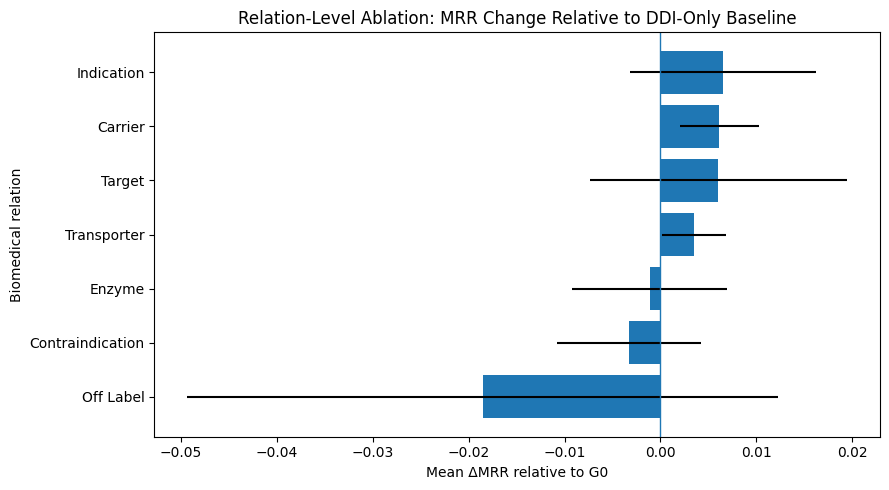

Saved: /workspace/primekg_ddi_rgcn/figures/relation_ablation_delta_mrr.png


In [63]:
import matplotlib.pyplot as plt

plot_df = final_ablation.copy()

plot_df["Relation"] = (
    plot_df["graph"]
    .str.replace("A1_", "", regex=False)
    .str.replace("A2_", "", regex=False)
    .str.replace("A3_", "", regex=False)
    .str.replace("A4_", "", regex=False)
    .str.replace("A5_", "", regex=False)
    .str.replace("A6_", "", regex=False)
    .str.replace("A7_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

plot_df = plot_df.sort_values(
    "DeltaMRR_mean"
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["Relation"],
    plot_df["DeltaMRR_mean"],
    xerr=plot_df["DeltaMRR_std"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Mean ΔMRR relative to G0")
plt.ylabel("Biomedical relation")

plt.title(
    "Relation-Level Ablation: "
    "MRR Change Relative to DDI-Only Baseline"
)

plt.tight_layout()

figure_path = (
    PROJECT_DIR
    / "figures/relation_ablation_delta_mrr.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

In [64]:
# ============================================================
# FINAL 3-SEED RELATION-LEVEL ABLATION SUMMARY
# ============================================================

import pandas as pd
from pathlib import Path

# Original forward biomedical edge counts
BIOMEDICAL_EDGES = {
    "A1_target": 16380,
    "A2_enzyme": 5317,
    "A3_transporter": 3092,
    "A4_carrier": 864,
    "A5_indication": 9388,
    "A6_contraindication": 30675,
    "A7_off_label": 2568,
}

RELATION_NAMES = {
    "A1_target": "Target",
    "A2_enzyme": "Enzyme",
    "A3_transporter": "Transporter",
    "A4_carrier": "Carrier",
    "A5_indication": "Indication",
    "A6_contraindication": "Contraindication",
    "A7_off_label": "Off-label use",
}


# ------------------------------------------------------------
# 1. Mean ± SD across seeds 42, 43, 44
# ------------------------------------------------------------

performance_summary = (
    df.groupby("graph")
      .agg(
          MRR_mean=("MRR", "mean"),
          MRR_std=("MRR", "std"),

          Hits1_mean=("Hits@1", "mean"),
          Hits1_std=("Hits@1", "std"),

          Hits3_mean=("Hits@3", "mean"),
          Hits3_std=("Hits@3", "std"),

          Hits5_mean=("Hits@5", "mean"),
          Hits5_std=("Hits@5", "std"),

          Hits10_mean=("Hits@10", "mean"),
          Hits10_std=("Hits@10", "std"),

          MeanRank_mean=("MeanRank", "mean"),
          MeanRank_std=("MeanRank", "std"),
      )
      .reset_index()
)


# ------------------------------------------------------------
# 2. Paired ΔMRR against G0
# ------------------------------------------------------------

delta_summary = (
    delta_df.groupby("graph")
            .agg(
                DeltaMRR_mean=("delta_MRR", "mean"),
                DeltaMRR_std=("delta_MRR", "std"),
                DeltaMRR_min=("delta_MRR", "min"),
                DeltaMRR_max=("delta_MRR", "max"),

                PositiveSeeds=(
                    "delta_MRR",
                    lambda x: int((x > 0).sum())
                )
            )
            .reset_index()
)


# ------------------------------------------------------------
# 3. Merge
# ------------------------------------------------------------

final_ablation = performance_summary.merge(
    delta_summary,
    on="graph"
)

final_ablation["Relation"] = (
    final_ablation["graph"]
    .map(RELATION_NAMES)
)

final_ablation["BiomedicalEdges"] = (
    final_ablation["graph"]
    .map(BIOMEDICAL_EDGES)
)

# Reverse edges are also included in the R-GCN graph
final_ablation["BiomedicalDirectedEdges"] = (
    final_ablation["BiomedicalEdges"] * 2
)

final_ablation["PositiveSeedsTotal"] = (
    final_ablation["PositiveSeeds"]
    .astype(str)
    + "/3"
)


# ------------------------------------------------------------
# 4. Add G0 reference statistics
# ------------------------------------------------------------

g0_mrr_mean = g0_df["MRR"].mean()
g0_mrr_std = g0_df["MRR"].std()

final_ablation["G0_MRR_mean"] = g0_mrr_mean
final_ablation["G0_MRR_std"] = g0_mrr_std


# ------------------------------------------------------------
# 5. Sort by mean ΔMRR
# ------------------------------------------------------------

final_ablation = (
    final_ablation
    .sort_values(
        "DeltaMRR_mean",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Nice formatted columns for viewing
# ------------------------------------------------------------

final_ablation["MRR_mean_std"] = (
    final_ablation.apply(
        lambda r:
        f"{r['MRR_mean']:.6f} ± {r['MRR_std']:.6f}",
        axis=1
    )
)

final_ablation["DeltaMRR_mean_std"] = (
    final_ablation.apply(
        lambda r:
        f"{r['DeltaMRR_mean']:+.6f} ± {r['DeltaMRR_std']:.6f}",
        axis=1
    )
)


print(
    f"G0 3-seed MRR = "
    f"{g0_mrr_mean:.6f} ± {g0_mrr_std:.6f}"
)

display(
    final_ablation[
        [
            "Relation",
            "BiomedicalEdges",
            "MRR_mean_std",
            "DeltaMRR_mean_std",
            "PositiveSeedsTotal",
            "Hits1_mean",
            "Hits5_mean",
            "Hits10_mean",
            "MeanRank_mean",
        ]
    ]
)

G0 3-seed MRR = 0.529118 ± 0.008136


,Relation,BiomedicalEdges,MRR_mean_std,DeltaMRR_mean_std,PositiveSeedsTotal,Hits1_mean,Hits5_mean,Hits10_mean,MeanRank_mean
0,Indication,9388,0.535659 ± 0.008666,+0.006542 ± 0.009709,2/3,0.488342,0.580953,0.618170,122.414190
1,Carrier,864,0.535263 ± 0.005680,+0.006145 ± 0.004079,3/3,0.489220,0.579763,0.615507,122.498395
2,Target,16380,0.535154 ± 0.009967,+0.006036 ± 0.013416,2/3,0.488838,0.579732,0.615822,123.627502
3,Transporter,3092,0.532645 ± 0.010348,+0.003528 ± 0.003327,3/3,0.487096,0.576221,0.612906,124.223132
4,Enzyme,5317,0.527979 ± 0.002269,-0.001138 ± 0.008076,1/3,0.481283,0.572877,0.610263,128.730710
5,Contraindication,30675,0.525807 ± 0.003087,-0.003311 ± 0.007487,1/3,0.478529,0.571935,0.608791,128.603477
6,Off-label use,2568,0.510576 ± 0.038774,-0.018541 ± 0.030788,1/3,0.466068,0.551745,0.587364,146.175733


In [65]:
# ============================================================
# SAVE FINAL SUMMARY CSV
# ============================================================

FINAL_DIR = (
    PROJECT_DIR
    / "results/relation_ablation/final"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary_csv = (
    FINAL_DIR
    / "relation_ablation_3seed_summary.csv"
)

final_ablation.to_csv(
    summary_csv,
    index=False
)

print("Saved final summary:")
print(summary_csv)

Saved final summary:
/workspace/primekg_ddi_rgcn/results/relation_ablation/final/relation_ablation_3seed_summary.csv


In [66]:
# ============================================================
# SAVE PER-SEED PAIRED DELTAS
# ============================================================

paired_csv = (
    FINAL_DIR
    / "relation_ablation_paired_deltas_vs_G0.csv"
)

delta_df.to_csv(
    paired_csv,
    index=False
)

print("Saved paired results:")
print(paired_csv)

Saved paired results:
/workspace/primekg_ddi_rgcn/results/relation_ablation/final/relation_ablation_paired_deltas_vs_G0.csv


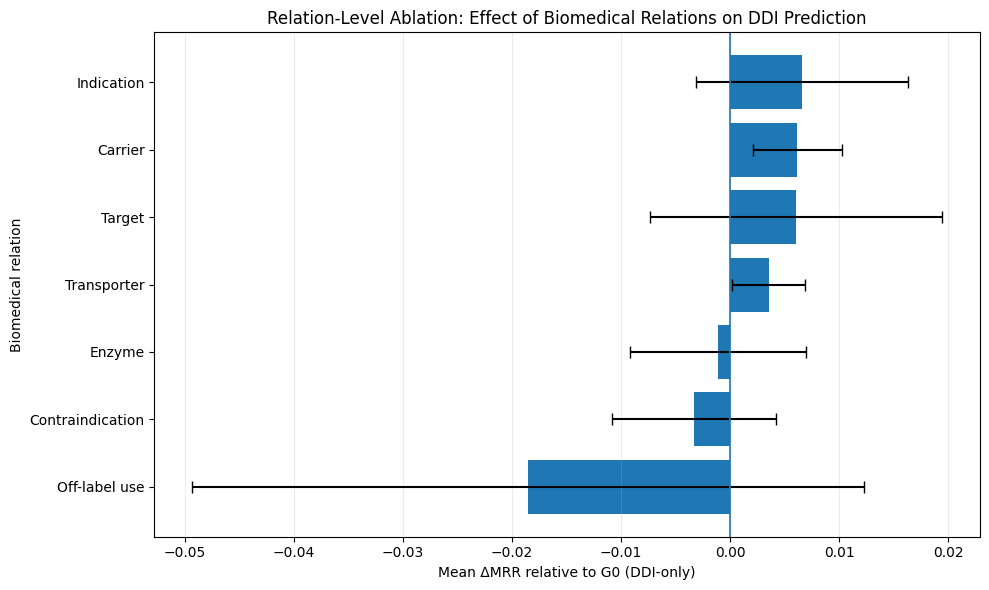

PNG saved:
/workspace/primekg_ddi_rgcn/figures/relation_ablation_delta_mrr_3seed.png

PDF saved:
/workspace/primekg_ddi_rgcn/figures/relation_ablation_delta_mrr_3seed.pdf


In [67]:
# ============================================================
# FINAL FIGURE:
# Mean ΔMRR relative to G0
# ============================================================

import matplotlib.pyplot as plt

plot_df = final_ablation.copy()

# Ascending order works well for horizontal bars:
# worst at bottom, strongest at top.
plot_df = plot_df.sort_values(
    "DeltaMRR_mean",
    ascending=True
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    plot_df["Relation"],
    plot_df["DeltaMRR_mean"],
    xerr=plot_df["DeltaMRR_std"],
    capsize=4
)

# G0 baseline
plt.axvline(
    x=0,
    linewidth=1.2
)

plt.xlabel(
    "Mean ΔMRR relative to G0 (DDI-only)"
)

plt.ylabel(
    "Biomedical relation"
)

plt.title(
    "Relation-Level Ablation: "
    "Effect of Biomedical Relations on DDI Prediction"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


# ------------------------------------------------------------
# Save high-resolution PNG
# ------------------------------------------------------------

figure_png = (
    PROJECT_DIR
    / "figures/relation_ablation_delta_mrr_3seed.png"
)

plt.savefig(
    figure_png,
    dpi=300,
    bbox_inches="tight"
)


# ------------------------------------------------------------
# Save vector PDF version too
# ------------------------------------------------------------

figure_pdf = (
    PROJECT_DIR
    / "figures/relation_ablation_delta_mrr_3seed.pdf"
)

plt.savefig(
    figure_pdf,
    bbox_inches="tight"
)

plt.show()

print("PNG saved:")
print(figure_png)

print("\nPDF saved:")
print(figure_pdf)

In [68]:
# ============================================================
# VERIFY FINAL FILES
# ============================================================

files_to_check = [
    summary_csv,
    paired_csv,
    figure_png,
    figure_pdf,
]

print("FINAL OUTPUT CHECK")
print("=" * 70)

for path in files_to_check:

    exists = path.exists()

    size = (
        path.stat().st_size / 1024
        if exists
        else 0
    )

    print(
        f"{'OK' if exists else 'MISSING'} | "
        f"{size:.1f} KB | "
        f"{path}"
    )

FINAL OUTPUT CHECK
OK | 3.4 KB | /workspace/primekg_ddi_rgcn/results/relation_ablation/final/relation_ablation_3seed_summary.csv
OK | 1.6 KB | /workspace/primekg_ddi_rgcn/results/relation_ablation/final/relation_ablation_paired_deltas_vs_G0.csv
OK | 125.9 KB | /workspace/primekg_ddi_rgcn/figures/relation_ablation_delta_mrr_3seed.png
OK | 17.5 KB | /workspace/primekg_ddi_rgcn/figures/relation_ablation_delta_mrr_3seed.pdf
